In [1]:
import pandas as pd
import numpy as np
from bromo.evaluations.tka import eval_curve_list, eval_q1_dataframes,eval_q1_scores 

### 1. Replicate TKA plot for: human-astral

In [2]:
astral_human = pd.read_csv('../../Datasets/preprocessing/diann_outputs/human-astral/report.tsv',sep='\t')
astral_human = astral_human[['Run','Protein.Group','Stripped.Sequence','Precursor.Charge','Precursor.Normalised']]
astral_human['peptide_id'] = astral_human['Protein.Group'] + ':' + astral_human['Stripped.Sequence'] + ':' + astral_human['Precursor.Charge'].astype(str)
astral_human_30 = astral_human[astral_human['Run']=='Ast_20240130_Bo_AI_30_2mz_HeLa01']
astral_human_38 = astral_human[astral_human['Run']=='Ast_20240130_Bo_AI_38_2mz_HeLa03']
astral_human_30.set_index('peptide_id',inplace=True)
astral_human_38.set_index('peptide_id',inplace=True)
common = np.intersect1d(astral_human_30.index,astral_human_38.index)
astral_human_30 = astral_human_30.loc[common]
astral_human_38 = astral_human_38.loc[common]
del astral_human

astral_human_38.rename(columns={'Precursor.Normalised':'pred_label'},inplace=True)
astral_human_30.rename(columns={'Precursor.Normalised':'label'},inplace=True)
astral_human_30['pred_label'] = astral_human_38['pred_label']
del astral_human_38
astral_human_30['unique_prots'] = astral_human_30['Protein.Group'].str.split(';')
astral_human_30 = astral_human_30[astral_human_30['unique_prots'].apply(len) == 1]
astral_human_30.rename(columns={'Protein.Group':'protein'},inplace=True)
astral_human_30['peptide'] = astral_human_30.index

In [3]:
results = eval_q1_scores(
    astral_human_30,
    topk=5,
    true_col="label",
    pred_cols=["pred_label"],
)


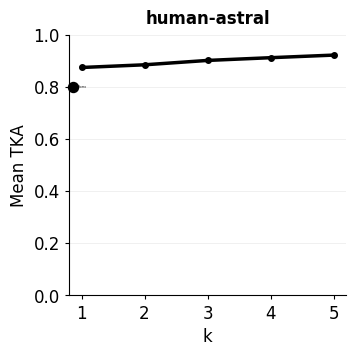

In [4]:
curve_dicts_q1_astralhuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-astral',
    save_path = './fig_astralhumanreplicates.pdf',
    curve_dicts = [results['pred_label']],
    ttest_show = False,
    colors = ["#000000"],
    tick_fs = 12,
    label_fs = 12,
    title_fs = 12,
    legend_fs = 2)


### 2.Replicate TKA plot for: human-exploris

In [5]:
exploris_human = pd.read_csv('../../Datasets/preprocessing/diann_outputs/human-exploris/report.tsv',sep='\t')
exploris_human = exploris_human[['Run','Protein.Group','Stripped.Sequence','Precursor.Charge','Precursor.Normalised']]
exploris_human['peptide_id'] = exploris_human['Protein.Group'] + ':' + exploris_human['Stripped.Sequence'] + ':' + exploris_human['Precursor.Charge'].astype(str)
exploris_human_240 = exploris_human[exploris_human['Run']=='Dora_20240323_Neo_240_HeLa_8mz_staggered_27NCE_01']
exploris_human_241 = exploris_human[exploris_human['Run']=='Dora_20240323_Neo_241_HeLa_8mz_staggered_27NCE_02']
exploris_human_240.set_index('peptide_id',inplace=True)
exploris_human_241.set_index('peptide_id',inplace=True)
common = np.intersect1d(exploris_human_240.index,exploris_human_241.index)
exploris_human_240 = exploris_human_240.loc[common]
exploris_human_241 = exploris_human_241.loc[common]
del exploris_human

exploris_human_241.rename(columns={'Precursor.Normalised':'pred_label'},inplace=True)
exploris_human_240.rename(columns={'Precursor.Normalised':'label'},inplace=True)
exploris_human_240['pred_label'] = exploris_human_241['pred_label']
del exploris_human_241
exploris_human_240['unique_prots'] = exploris_human_240['Protein.Group'].str.split(';')
exploris_human_240 = exploris_human_240[exploris_human_240['unique_prots'].apply(len) == 1]
exploris_human_240.rename(columns={'Protein.Group':'protein'},inplace=True)
exploris_human_240['peptide'] = exploris_human_240.index

In [6]:
results = eval_q1_scores(
    exploris_human_240,
    topk=5,
    true_col="label",
    pred_cols=["pred_label"],
)


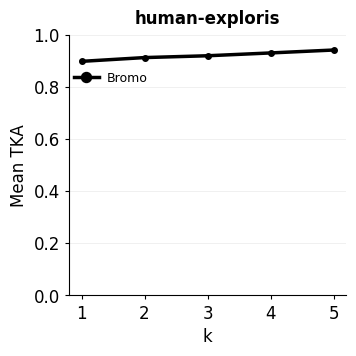

In [7]:
curve_dicts_q1_explorishuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-exploris',
    save_path = './fig_explorishumanreplicates.pdf',
    curve_dicts = [results['pred_label']],
    ttest_show = False,
    colors = ["#000000"])


### 3.Replicate TKA plot for: human-lumos

In [8]:
lumos_human = pd.read_csv('../../Datasets/preprocessing/diann_outputs/human-lumos/report.tsv',sep='\t')
lumos_human = lumos_human[['Run','Protein.Group','Stripped.Sequence','Precursor.Charge','Precursor.Normalised']]
lumos_human['peptide_id'] = lumos_human['Protein.Group'] + ':' + lumos_human['Stripped.Sequence'] + ':' + lumos_human['Precursor.Charge'].astype(str)
lumos_human_7 = lumos_human[lumos_human['Run']=='Loo_20240205_BoAI_07_8mz_HeLa01']
lumos_human_15 = lumos_human[lumos_human['Run']=='Loo_20240205_BoAI_15_8mz_HeLa03']
lumos_human_7.set_index('peptide_id',inplace=True)
lumos_human_15.set_index('peptide_id',inplace=True)
common = np.intersect1d(lumos_human_7.index,lumos_human_15.index)
lumos_human_7 = lumos_human_7.loc[common]
lumos_human_15 = lumos_human_15.loc[common]
del lumos_human

lumos_human_7.rename(columns={'Precursor.Normalised':'pred_label'},inplace=True)
lumos_human_15.rename(columns={'Precursor.Normalised':'label'},inplace=True)
lumos_human_15['pred_label'] = lumos_human_7['pred_label']
del lumos_human_7
lumos_human_15['unique_prots'] = lumos_human_15['Protein.Group'].str.split(';')
lumos_human_15 = lumos_human_15[lumos_human_15['unique_prots'].apply(len) == 1]
lumos_human_15.rename(columns={'Protein.Group':'protein'},inplace=True)
lumos_human_15['peptide'] = lumos_human_15.index

In [9]:
results = eval_q1_scores(
    lumos_human_15,
    topk=5,
    true_col="label",
    pred_cols=["pred_label"],
)


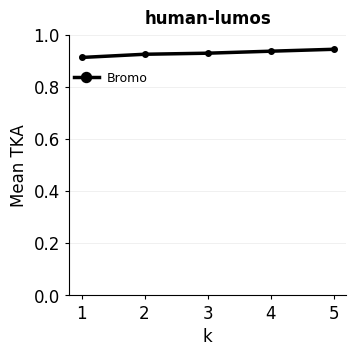

In [10]:
curve_dicts_q1_lumoshuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-lumos',
    save_path = './fig_lumoshumanreplicates.pdf',
    curve_dicts = [results['pred_label']],
    ttest_show = False,
    colors = ["#000000"])


### 4.Replicate TKA plot for: human-pan

In [11]:
hek293 = pd.read_parquet('../../Datasets/preprocessing/diann_outputs/human-pan/merged_df_filtered_Control_HEK293T_std_H002.parquet')
hek293 = hek293[['File.Name','Protein.Group','Stripped.Sequence','Precursor.Charge','Precursor.Normalised']]
hek293['peptide_id'] = hek293['Protein.Group'] + ':' + hek293['Stripped.Sequence'] + ':' + hek293['Precursor.Charge'].astype(str)
hek293_716 = hek293[hek293['File.Name']=='./180822_e0022_p02_hek_h002_qc_s_m04_1.dia']
hek293_915 = hek293[hek293['File.Name']=='./180822_e0022_p02_hek_h002_qc_s_m04_2.dia']
hek293_716.set_index('peptide_id',inplace=True)
hek293_915.set_index('peptide_id',inplace=True)
common = np.intersect1d(hek293_716.index,hek293_915.index)
hek293_716 = hek293_716.loc[common]
hek293_915 = hek293_915.loc[common]
del hek293

hek293_716.rename(columns={'Precursor.Normalised':'pred_label'},inplace=True)
hek293_915.rename(columns={'Precursor.Normalised':'label'},inplace=True)
hek293_915['pred_label'] = hek293_716['pred_label']
hek293_915['unique_prots'] = hek293_915['Protein.Group'].str.split(';')
hek293_915 = hek293_915[hek293_915['unique_prots'].apply(len) == 1]
hek293_915.rename(columns={'Protein.Group':'protein'},inplace=True)
hek293_915['peptide'] = hek293_915.index

In [12]:
results = eval_q1_scores(
    hek293_915,
    topk=5,
    true_col="label",
    pred_cols=["pred_label"],
)


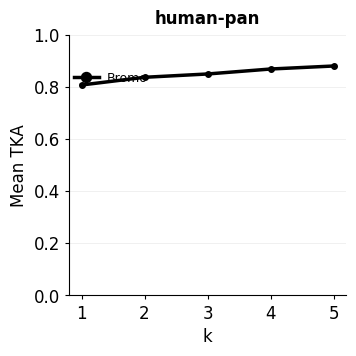

In [13]:
curve_dicts_q1_pansameday = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-pan',
    save_path = './fig_cancerreplicates_sameday.pdf',
    curve_dicts = [results['pred_label']],
    ttest_show = False,
    colors = ["#000000"])


### 5.Cross-Instrument TKA plot for: human-pan vs. human-astral

In [31]:
cancer_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-pan/consensus_label_corrected.tsv',sep='\t')
astral_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-astral/consensus_label_corrected.tsv',sep='\t')

astral_train["peptide_pair"] = (
    astral_train["peptide_a"] + ":" + astral_train["peptide_b"]
)
cancer_train["peptide_pair"] = (
    cancer_train["peptide_a"] + ":" + cancer_train["peptide_b"]
)

astral_train.set_index("peptide_pair", inplace=True)
cancer_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(astral_train.index, cancer_train.index)

cancer_train = cancer_train.loc[common]
astral_train = astral_train.loc[common]

cancer_train_fwd = cancer_train[cancer_train.pair_key.duplicated()]
astral_train_fwd = astral_train[cancer_train.pair_key.duplicated()]

cancer_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
cancer_train_fwd['label']=astral_train_fwd['label']
del astral_train_fwd, astral_train, cancer_train

/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2767038983.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancer_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2767038983.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancer_train_fwd['label']=astral_train_fwd['label']


In [32]:
trues, preds = eval_q1_dataframes(cancer_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

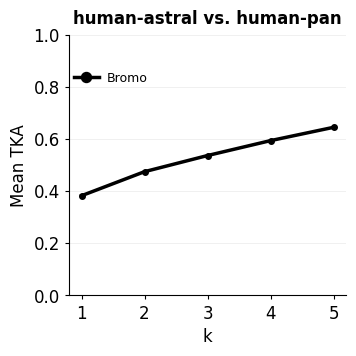

In [33]:
curve_dicts_q1_astralvcancer = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-astral vs. human-pan',
    save_path = './fig_astralhumanvscancer.pdf',
    curve_dicts = [results["pred_wins"]],
    ttest_show = False,
    colors = ["#000000"])


### 6.Cross-Instrument TKA plot for: human-lumos vs. human-astral

In [34]:
lumos_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-lumos/consensus_label_corrected.tsv',sep='\t')
astral_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-astral/consensus_label_corrected.tsv',sep='\t')

astral_train["peptide_pair"] = (
    astral_train["peptide_a"] + ":" + astral_train["peptide_b"]
)
lumos_train["peptide_pair"] = (
    lumos_train["peptide_a"] + ":" + lumos_train["peptide_b"]
)

astral_train.set_index("peptide_pair", inplace=True)
lumos_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(astral_train.index, lumos_train.index)

lumos_train = lumos_train.loc[common]
astral_train = astral_train.loc[common]

lumos_train_fwd = lumos_train[lumos_train.pair_key.duplicated()]
astral_train_fwd = astral_train[lumos_train.pair_key.duplicated()]

lumos_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
lumos_train_fwd['label']=astral_train_fwd['label']
del astral_train_fwd, astral_train, lumos_train


/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/3754939165.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lumos_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/3754939165.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lumos_train_fwd['label']=astral_train_fwd['label']


In [35]:
trues, preds = eval_q1_dataframes(lumos_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

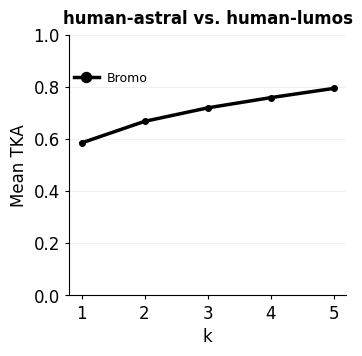

In [36]:
curve_dicts_q1_astralvlumoshuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-astral vs. human-lumos',
    save_path = './fig_astralhumanvslumoshuman.pdf',
    curve_dicts = [results["pred_wins"]],
    ttest_show = False,
    colors = ["#000000"])


### 7.Cross-Instrument TKA plot for: human-exploris vs. human-astral

In [37]:
exploris_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-exploris/consensus_label_corrected.tsv',sep='\t')
astral_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-astral/consensus_label_corrected.tsv',sep='\t')

astral_train["peptide_pair"] = (
    astral_train["peptide_a"] + ":" + astral_train["peptide_b"]
)
exploris_train["peptide_pair"] = (
    exploris_train["peptide_a"] + ":" + exploris_train["peptide_b"]
)

astral_train.set_index("peptide_pair", inplace=True)
exploris_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(astral_train.index, exploris_train.index)

exploris_train = exploris_train.loc[common]
astral_train = astral_train.loc[common]

exploris_train_fwd = exploris_train[exploris_train.pair_key.duplicated()]
astral_train_fwd = astral_train[exploris_train.pair_key.duplicated()]

exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
exploris_train_fwd['label']=astral_train_fwd['label']
del astral_train_fwd, astral_train, exploris_train


/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/1338436167.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/1338436167.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd['label']=astral_train_fwd['label']


In [38]:
trues, preds = eval_q1_dataframes(exploris_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

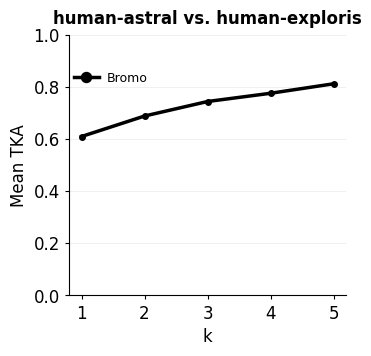

In [39]:
curve_dicts_q1_astralvexplorishuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-astral vs. human-exploris',
    save_path = './fig_astralhumanvsexplorishuman.pdf',
    curve_dicts = [results['pred_wins']],
    ttest_show = False,
    colors = ["#000000"])


### 8.Cross-Instrument TKA plot for: human-exploris vs. human-lumos

In [40]:
exploris_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-exploris/consensus_label_corrected.tsv',sep='\t')
lumos_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-lumos/consensus_label_corrected.tsv',sep='\t')

lumos_train["peptide_pair"] = (
    lumos_train["peptide_a"] + ":" + lumos_train["peptide_b"]
)
exploris_train["peptide_pair"] = (
    exploris_train["peptide_a"] + ":" + exploris_train["peptide_b"]
)

lumos_train.set_index("peptide_pair", inplace=True)
exploris_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(lumos_train.index, exploris_train.index)

exploris_train = exploris_train.loc[common]
lumos_train = lumos_train.loc[common]

exploris_train_fwd = exploris_train[exploris_train.pair_key.duplicated()]
lumos_train_fwd = lumos_train[exploris_train.pair_key.duplicated()]

exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
exploris_train_fwd['label']=lumos_train_fwd['label']
del lumos_train_fwd, lumos_train, exploris_train


/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/4145930205.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/4145930205.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd['label']=lumos_train_fwd['label']


In [41]:
trues, preds = eval_q1_dataframes(exploris_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

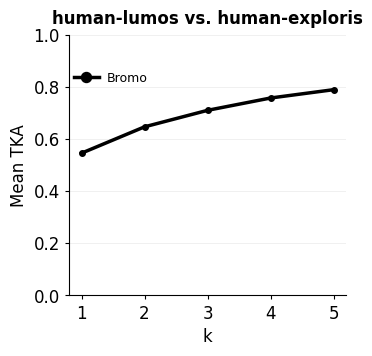

In [42]:
curve_dicts_q1_lumovexplorishuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-lumos vs. human-exploris',
    save_path = './fig_lumoshumanvsexplorishuman.pdf',
    curve_dicts = [results['pred_wins']],
    ttest_show = False,
    colors = ["#000000"])


### 9.Cross-Instrument TKA plot for: human-exploris vs. human-pan

In [43]:
exploris_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-exploris/consensus_label_corrected.tsv',sep='\t')
cancer_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-pan/consensus_label_corrected.tsv',sep='\t')

cancer_train["peptide_pair"] = (
    cancer_train["peptide_a"] + ":" + cancer_train["peptide_b"]
)
exploris_train["peptide_pair"] = (
    exploris_train["peptide_a"] + ":" + exploris_train["peptide_b"]
)

cancer_train.set_index("peptide_pair", inplace=True)
exploris_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(cancer_train.index, exploris_train.index)

exploris_train = exploris_train.loc[common]
cancer_train = cancer_train.loc[common]

exploris_train_fwd = exploris_train[exploris_train.pair_key.duplicated()]
cancer_train_fwd = cancer_train[exploris_train.pair_key.duplicated()]

exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
exploris_train_fwd['label']=cancer_train_fwd['label']
del cancer_train_fwd, cancer_train, exploris_train


/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2457199597.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2457199597.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exploris_train_fwd['label']=cancer_train_fwd['label']


In [44]:
trues, preds = eval_q1_dataframes(exploris_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

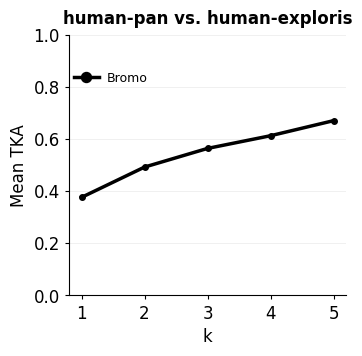

In [45]:
curve_dicts_q1_cancervsexploris = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-pan vs. human-exploris',
    save_path = './fig_cancervsexplorishuman.pdf',
    curve_dicts = [results['pred_wins']],
    ttest_show = False,
    colors = ["#000000"])


### 10.Cross-Instrument TKA plot for: human-lumos vs. human-pan

In [46]:
lumos_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-lumos/consensus_label_corrected.tsv',sep='\t')
cancer_train = pd.read_csv('../../Datasets/preprocessing/assign_labels/human-pan/consensus_label_corrected.tsv',sep='\t')

cancer_train["peptide_pair"] = (
    cancer_train["peptide_a"] + ":" + cancer_train["peptide_b"]
)
lumos_train["peptide_pair"] = (
    lumos_train["peptide_a"] + ":" + lumos_train["peptide_b"]
)

cancer_train.set_index("peptide_pair", inplace=True)
lumos_train.set_index("peptide_pair", inplace=True)

common = np.intersect1d(cancer_train.index, lumos_train.index)

lumos_train = lumos_train.loc[common]
cancer_train = cancer_train.loc[common]

lumos_train_fwd = lumos_train[lumos_train.pair_key.duplicated()]
cancer_train_fwd = cancer_train[lumos_train.pair_key.duplicated()]

lumos_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
lumos_train_fwd['label']=cancer_train_fwd['label']
del cancer_train_fwd, cancer_train, lumos_train

/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2837829471.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lumos_train_fwd.rename(columns={'label':'pred_label'},inplace=True)
/tmp/20198726.1.pinglay-login.q/ipykernel_2932472/2837829471.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lumos_train_fwd['label']=cancer_train_fwd['label']


In [47]:
trues, preds = eval_q1_dataframes(lumos_train_fwd, 5, break_ties_bool=False)
ranks = trues.merge(preds, on=['protein','peptide','pred_wins','true_wins'])
results = eval_q1_scores(
    ranks,
    topk=5,
    true_col="true_wins",
    pred_cols=["pred_wins"],
)

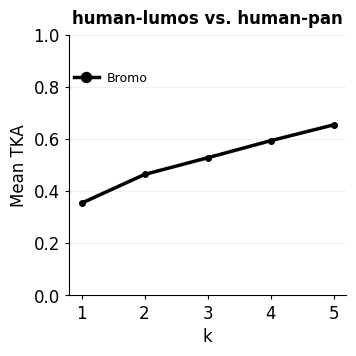

In [ ]:
curve_dicts_q1_cancervslumoshuman = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo'],
    title = 'human-lumos vs. human-pan',
    save_path = './fig_cancervslumoshuman.pdf',
    curve_dicts = [results['pred_wins']],
    ttest_show = False,
    colors = ["#000000"])


### 11.Aggregate TKA plot for: human-astral

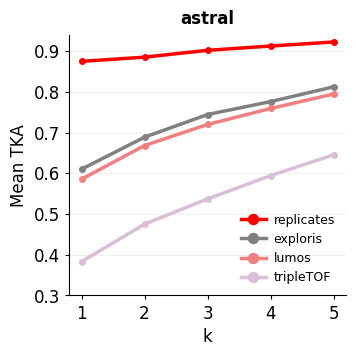

In [56]:
curve_dicts_q1_astral = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['replicates','exploris','lumos','tripleTOF'],
    title = 'astral',
    save_path = './fig3d_astralhumanvotherinstruments.pdf',
    curve_dicts = [curve_dicts_q1_astralhuman[0][0],curve_dicts_q1_astralvexplorishuman[0][0],curve_dicts_q1_astralvlumoshuman[0][0],curve_dicts_q1_astralvcancer[0][0]],
    ttest_show = False,
    colors = ["red","grey","lightcoral","thistle"],
    legend_loc = 'lower right',
    ylim = (0.3,0.94))


### 12.Aggregate TKA plot for: human-exploris

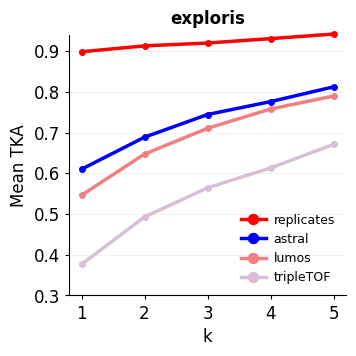

In [57]:
curve_dicts_q1_exploris = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['replicates','astral','lumos','tripleTOF'],
    title = 'exploris',
    save_path = './fig3a_explorishumanvotherinstruments.pdf',
    curve_dicts = [curve_dicts_q1_explorishuman[0][0],curve_dicts_q1_astralvexplorishuman[0][0],curve_dicts_q1_lumovexplorishuman[0][0],curve_dicts_q1_cancervsexploris[0][0]],
    ttest_show = False,
    legend_loc = 'lower right',
    colors = ["red","blue","lightcoral","thistle"],
    ylim = (0.3,0.94))


### 13.Aggregate TKA plot for: human-lumos

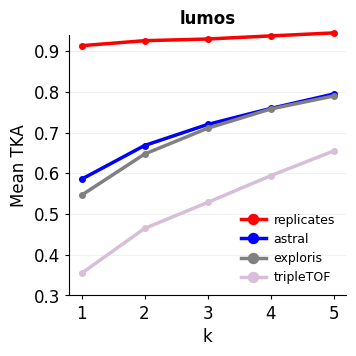

In [58]:
curve_dicts_q1_lumos = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['replicates','astral','exploris','tripleTOF'],
    title = 'lumos',
    save_path = './fig3b_lumoshumanvotherinstruments.pdf',
    curve_dicts = [curve_dicts_q1_lumoshuman[0][0],curve_dicts_q1_astralvlumoshuman[0][0],curve_dicts_q1_lumovexplorishuman[0][0],curve_dicts_q1_cancervslumoshuman[0][0]],
    ttest_show = False,
    legend_loc = 'lower right',
    colors = ["red","blue","grey","thistle"],
    ylim = (0.3,0.94))


### 14.Aggregate TKA plot for: human-pan

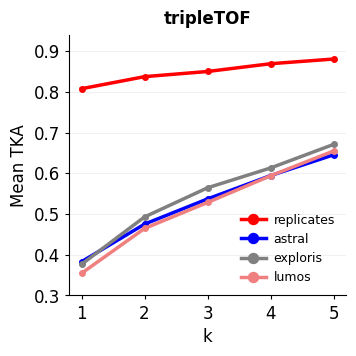

In [59]:
curve_dicts_q1_pan = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['replicates','astral','exploris','lumos'],
    title = 'tripleTOF',
    save_path = './fig3c_panhumanvotherinstruments.pdf',
    curve_dicts = [curve_dicts_q1_pansameday[0][0],curve_dicts_q1_astralvcancer[0][0],curve_dicts_q1_cancervsexploris[0][0],curve_dicts_q1_cancervslumoshuman[0][0]],
    ttest_show = False,
    legend_loc = 'lower right',
    colors = ["red","blue","grey","lightcoral"],
    ylim = (0.3,0.94))
